<a href="https://colab.research.google.com/github/mattsmiths/biol470/blob/main/final_project/FinalProject_Analysis_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
#@title Click to copy the class code repository
!git clone https://github.com/mattsmiths/biol470.git

Cloning into 'biol470'...
remote: Enumerating objects: 898, done.
remote: Counting objects: 100% (303/303), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 898 (delta 215), reused 222 (delta 158), pack-reused 595 (from 3)
Receiving objects: 100% (898/898), 932.34 MiB | 35.32 MiB/s, done.
Resolving deltas: 100% (373/373), done.
Updating files: 100% (353/353), done.


In [2]:
#@title Click to import libraries
import cv2 as cv
import os
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd

In [34]:
data1 = pd.read_csv('/content/biol470/final_project/nicotine_bee_1/assay4_inf_final_bee_0415_exp_01_air_cam1_2026-04-15_18-02-38_key.csv')

In [4]:
data1.head()

,Unnamed: 0,filepath,x_centroid,y_centroid,x_min,y_min,x_max,y_max,detection_confidence
0,0,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2866.5,2485.0,2499,2134,3234,2836,0.787689
1,1,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2863.5,2488.0,2513,2139,3214,2837,0.778611
2,2,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2863.5,2490.5,2511,2133,3216,2848,0.752090
3,3,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2824.0,2491.5,2478,2131,3170,2852,0.737394
4,4,/Volumes/SmithL0/2026/BIOL470/Final/0415/bee_0...,2813.5,2491.0,2458,2131,3169,2851,0.725658


In [5]:
x_store = []
y_store = []

# Pulling out the centroid for each detection event
for ind,ele in enumerate(data1['x_min']):
  x_center = (ele+data1['x_max'][ind])/2
  y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
  x_store.append(x_center)
  y_store.append(y_center)





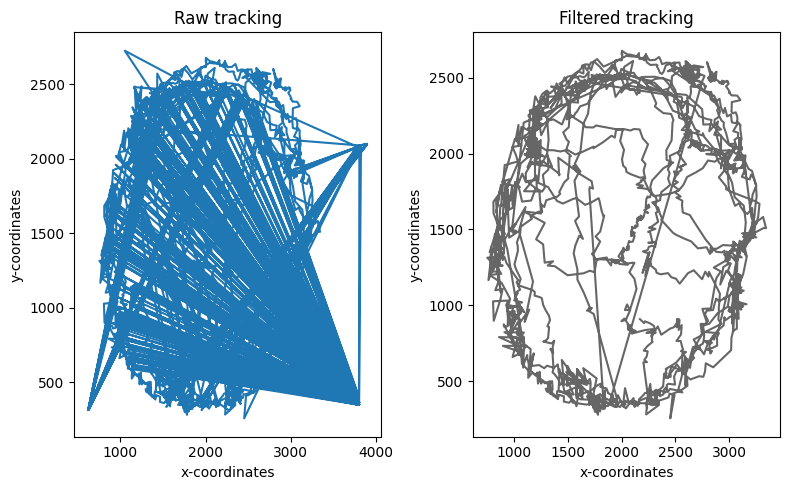

In [6]:
# Plotting the centroid in x-y space over time
# raw plot
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.title('Raw tracking')
plt.plot(x_store,y_store)
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')

speed = []
x_plot = []
y_plot = []
# updating to euclidean distance
for ind,x1 in enumerate(x_store[1:]):
  previous_pos = np.array([x_store[ind],y_store[ind]])
  current_pos = np.array([x_store[ind+1],y_store[ind+1]])

  # Euclidean distance calculation
  temp = np.linalg.norm((current_pos-previous_pos))

  speed.append(temp)

  # removing noise
  if temp < 250 and x_store[ind+1] < 3500:
    x_plot.append(x_store[ind+1])
    y_plot.append(y_store[ind+1])


plt.subplot(1,2,2)
plt.title('Filtered tracking')
plt.plot(x_plot,y_plot,color=(0.4,0.4,0.4))
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.tight_layout()


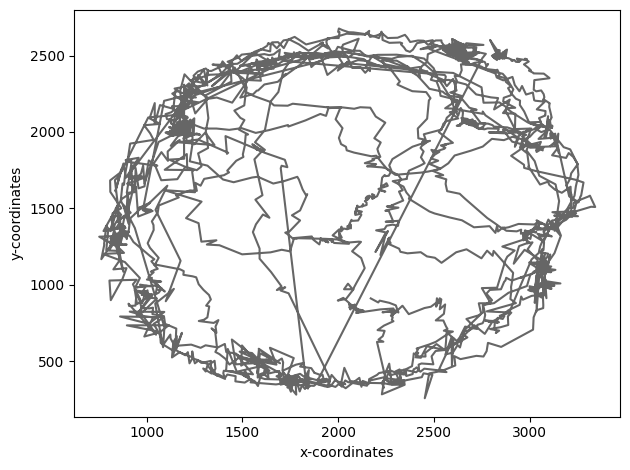

In [7]:

#plt.title('Filtered tracking')
plt.plot(x_plot,y_plot,color=(0.4,0.4,0.4))
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.tight_layout()
plt.savefig('/content/circle.jpg',dpi=200)

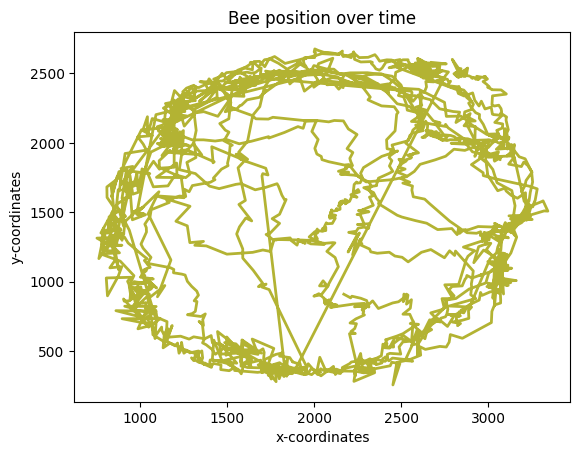

In [8]:
# Plotting the centroid in x-y space over time
plt.plot(x_plot,y_plot,color=(0.7,0.7,0.2),linewidth=2)
plt.xlabel('x-coordinates')
plt.ylabel('y-coordinates')
plt.title('Bee position over time')
plt.savefig('control_bee2_assay_1.pdf',dpi=200)

In [9]:
#xdiff = np.diff(x_store)
#ydiff = np.diff(y_store)
#out = abs(xdiff)+abs(ydiff)

speed = []
# updating to euclidean distance
for ind,x1 in enumerate(x_store[1:]):
  previous_pos = np.array([x_store[ind],y_store[ind]])
  current_pos = np.array([x_store[ind+1],y_store[ind+1]])

  # Euclidean distance calculation
  temp = np.linalg.norm((current_pos-previous_pos))

  speed.append(temp)

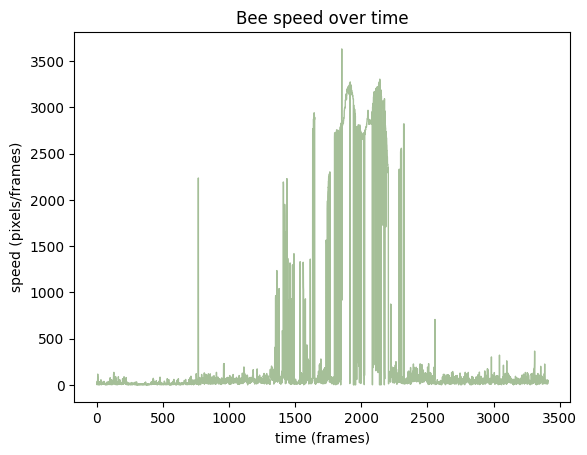

In [10]:
# Plotting the centroid in x-y space over time
plt.plot(speed,color=(0.3,0.5,0.2,0.5),linewidth=1)
plt.xlabel('time (frames)')
plt.ylabel('speed (pixels/frames)')
plt.title('Bee speed over time')
plt.savefig('control_bee2_assay_1_speed.pdf',dpi=200)

In [ ]:
assayList = ['/content/biol470/final_project/control_bee_2/assay1_inf_bee_0408_2_opto_2026-04-08_16-35-41_arena_circle_1_key.csv',
             '/content/biol470/final_project/control_bee_3/assay1_inf_bee_0408_3_opto_2026-04-08_17-28-06_arena_circle_1_key.csv',
             '/content/biol470/final_project/control_bee_4/assay1_inf_bee_0408_4_opto_2026-04-08_18-08-46_arena_circle_1_key.csv']

allStore_control = []
for bees in assayList:

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([x_store[ind],y_store[ind]])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)


  allStore_control.append(speed)

In [ ]:
assayList = ['/content/biol470/final_project/nicotine_bee_1/assay1_inf_bee_0415_exp_01_opto_2026-04-15_17-11-24_arena_circle_1_key.csv',
             '/content/biol470/final_project/nicotine_bee_2/assay1_inf_bee_0415_exp_02_opto_2026-04-15_20-58-17_arena_circle_1_key.csv',
             '/content/biol470/final_project/nicotine_bee_3/assay1_inf_bee_0415_exp_03_opto_2026-04-15_22-25-20_arena_circle_1_key.csv']

allStore = []
for bees in assayList:

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

    speed = []
    # updating to euclidean distance
    for ind,x1 in enumerate(x_store[1:]):
      previous_pos = np.array([x_store[ind],y_store[ind]])
      current_pos = np.array([x_store[ind+1],y_store[ind+1]])

      # Euclidean distance calculation
      temp = np.linalg.norm((current_pos-previous_pos))
      speed.append(temp)

  allStore.append(speed)

Text(0, 0.5, 'Avg Speed (pixels/frame)')

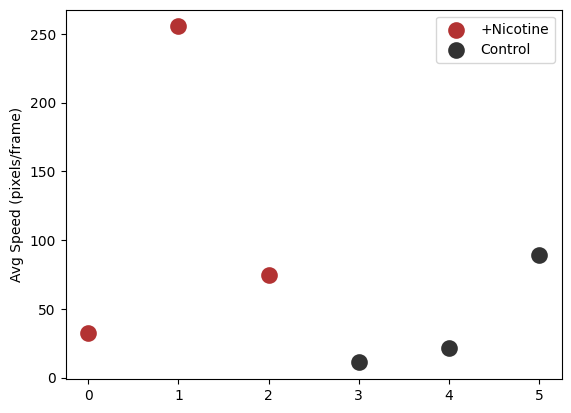

In [ ]:
plt.figure()
for ind,ele in enumerate(allStore):
  if ind == 0:
    plt.scatter(ind,np.nanmean(ele),color=(0.7,0.2,0.2),linewidth=2,s=100,label='+Nicotine')
  else:
    plt.scatter(ind,np.nanmean(ele),color=(0.7,0.2,0.2),linewidth=2,s=100)

for ind,ele in enumerate(allStore_control):
  if ind == 0:
    plt.scatter(ind+3,np.nanmean(ele),color=(0.2,0.2,0.2),linewidth=2,s=100,label='Control')
  else:
    plt.scatter(ind+3,np.nanmean(ele),color=(0.2,0.2,0.2),linewidth=2,s=100)
plt.legend()

plt.ylabel('Avg Speed (pixels/frame)')



# Arena Circle

In [41]:
findBees = glob.glob('/content/biol470/final_project/*/assay1*')

allStore = {}
for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}

  allStore[bees.split('/')[-2]]['Circle'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([x_store[ind],y_store[ind]])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Circle'].append(speed)

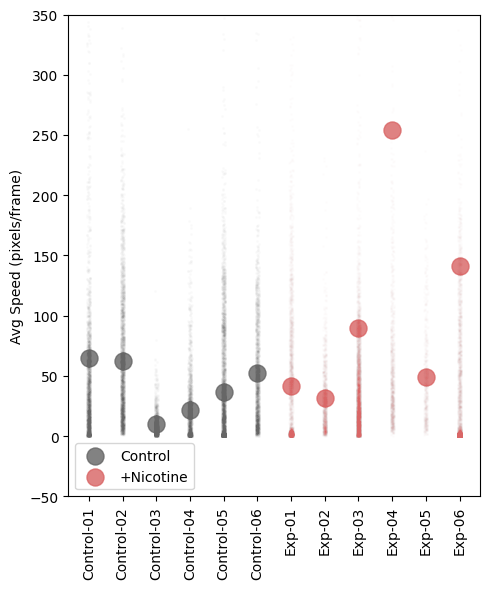

In [126]:
plt.figure(figsize=(5,6))
nbee = {}
nsbee = {}
cbee = {}
csbee = {}

for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    nbee[ele] = np.nanmean(allStore[ele]['Circle'])
    nsbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    cbee[ele] = np.nanmean(allStore[ele]['Circle'])
    csbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))



ind = 0

for ele in cbee:
  if ind == 0:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82),label='Control')
  else:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82))

  #plt.plot([ind,ind],[np.nanmean(cbee[ele])-csbee[ele],np.nanmean(cbee[ele])+csbee[ele]],color=(0.4,0.4,0.4,0.82))

  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.4,0.4,0.4,0.02),s=1)
  ind+=1

for ele in nbee:
  if ind == 6:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
  else:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82))

  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.85,0.4,0.4,0.01),s=1)
  ind+=1

plt.legend()
plt.xticks(np.arange(0,12),['Control-01','Control-02','Control-03','Control-04','Control-05','Control-06',
                            'Exp-01','Exp-02','Exp-03','Exp-04','Exp-05','Exp-06'],rotation=90)
plt.ylabel('Avg Speed (pixels/frame)')
plt.ylim([-50,350])
plt.tight_layout()
plt.savefig('/content/circle_speed.png',dpi=300)

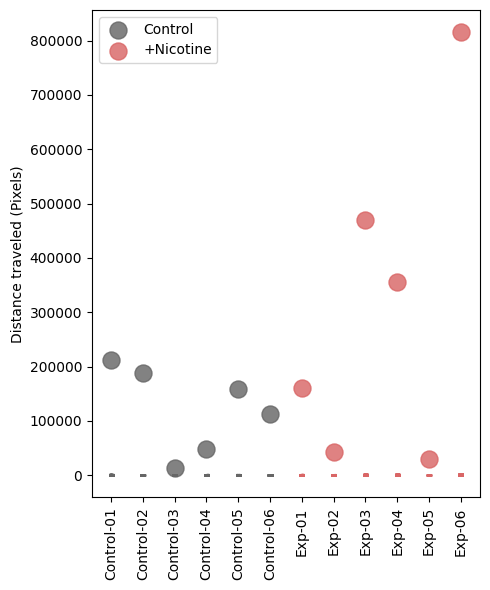

In [127]:
plt.figure(figsize=(5,6))
nbee = {}
nsbee = {}
cbee = {}
csbee = {}

for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    nbee[ele] = np.nansum(allStore[ele]['Circle'])
    nsbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    cbee[ele] = np.nansum(allStore[ele]['Circle'])
    csbee[ele] = np.nanstd(allStore[ele]['Circle'])/np.sqrt(len(allStore[ele]['Circle'][0]))



ind = 0

bbar = []
for ele in cbee:
  if ind == 0:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82),label='Control')
  else:
    plt.scatter(ind,np.nanmean(cbee[ele]),s=150,color=(0.4,0.4,0.4,0.82))
  bbar.append(cbee[ele])
  #plt.plot([ind,ind],[np.nanmean(cbee[ele])-csbee[ele],np.nanmean(cbee[ele])+csbee[ele]],color=(0.4,0.4,0.4,0.82))

  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.4,0.4,0.4,0.2),s=1)
  ind+=1

for ele in nbee:
  if ind == 6:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
  else:
    plt.scatter(ind,np.nanmean(nbee[ele]),s=150,color=(0.85,0.4,0.4,0.82))
  bbar.append(nbee[ele])
  dd = ((np.random.rand(len(allStore[ele]['Circle'][0]))*0.1)+ind-0.05)
  plt.scatter(dd,allStore[ele]['Circle'][0],color=(0.85,0.4,0.4,0.1),s=1)
  ind+=1

plt.legend()
plt.xticks(np.arange(0,12),['Control-01','Control-02','Control-03','Control-04','Control-05','Control-06',
                            'Exp-01','Exp-02','Exp-03','Exp-04','Exp-05','Exp-06'],rotation=90)
plt.ylabel('Distance traveled (Pixels)')
plt.tight_layout()
plt.savefig('/content/circle_dist.png',dpi=300)



/tmp/ipykernel_17187/2981826394.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


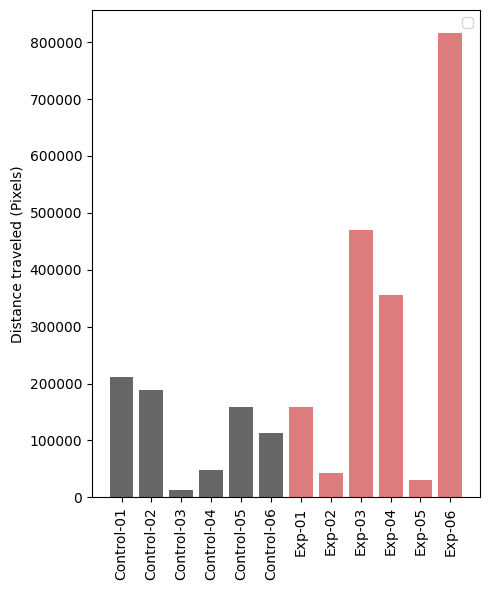

In [128]:
plt.figure(figsize=(5,6))
plt.bar(np.arange(0,6),bbar[:6],color=(0.4,0.4,0.4))
plt.bar(np.arange(6,12),bbar[6:],color=(0.85,0.4,0.4,0.85))
plt.legend()
plt.xticks(np.arange(0,12),['Control-01','Control-02','Control-03','Control-04','Control-05','Control-06',
                            'Exp-01','Exp-02','Exp-03','Exp-04','Exp-05','Exp-06'],rotation=90)
plt.ylabel('Distance traveled (Pixels)')
plt.tight_layout()
a1 = plt.axis()
plt.savefig('/content/circle_dist_bar.png',dpi=300)

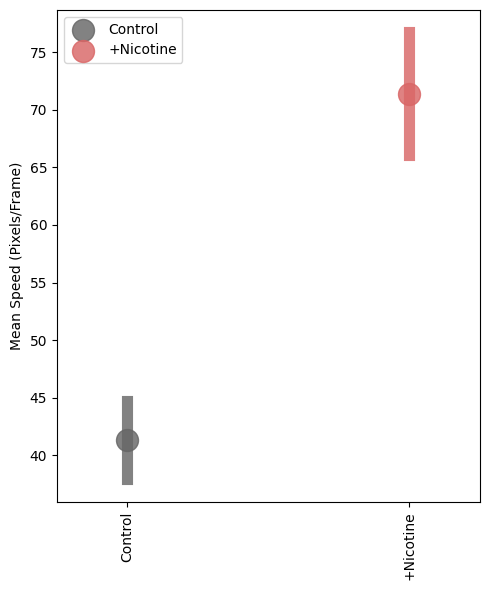

In [124]:
plt.figure(figsize=(5,6))
ff = []

for ele in cbee:
  ff.append(cbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
ind = 0
plt.scatter(ind,control_mean,s=250,color=(0.4,0.4,0.4,0.82),label='Control')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.4,0.4,0.4,0.82),linewidth=8)

ind+=1
for ele in nbee:
  ff.append(nbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
plt.scatter(ind,control_mean,s=250,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.85,0.4,0.4,0.82),linewidth=8)
plt.legend()
plt.ylabel('Mean Speed (Pixels/Frame)')
plt.xticks(np.arange(0,2),['Control','+Nicotine'],rotation=90)
plt.xlim([-0.25,1.25])

plt.tight_layout()
plt.savefig('/content/mean_comp_speed.png',dpi=300)

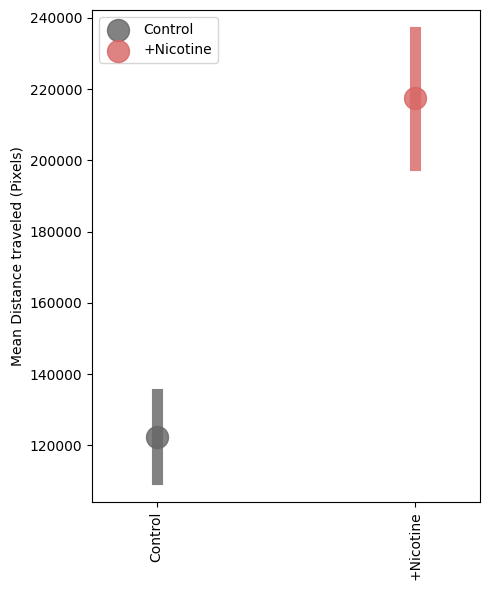

In [129]:
plt.figure(figsize=(5,6))
ff = []

for ele in cbee:
  ff.append(cbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
ind = 0
plt.scatter(ind,control_mean,s=250,color=(0.4,0.4,0.4,0.82),label='Control')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.4,0.4,0.4,0.82),linewidth=8)

ind+=1
for ele in nbee:
  ff.append(nbee[ele])
control_mean = np.nanmean(ff)
control_sem = np.nanstd(ff)/len(ff)
plt.scatter(ind,control_mean,s=250,color=(0.85,0.4,0.4,0.82),label='+Nicotine')
plt.plot([ind,ind],[control_mean-control_sem,control_mean+control_sem],color=(0.85,0.4,0.4,0.82),linewidth=8)
plt.legend()
plt.ylabel('Mean Distance traveled (Pixels)')
plt.xticks(np.arange(0,2),['Control','+Nicotine'],rotation=90)
plt.xlim([-0.25,1.25])

plt.tight_layout()

plt.tight_layout()
plt.savefig('/content/mean_comp_dist.png',dpi=300)

# Optomotor

In [5]:
import math

In [156]:
findBees = glob.glob('/content/biol470/final_project/*/assay2*fwd*')


for bees in findBees:

  allStore[bees.split('/')[-2]]['Opto'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []
  rad_store = []
  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  fx = []
  fy = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([2000,1500])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)
    fx.append(x_store[ind+1])
    fy.append(y_store[ind+1])
    #if temp < 500 and x_store[ind+1] > 1000:
    dx = 2000 - x_store[ind]
    dy = 1500 - y_store[ind]
    angle_rad = math.atan2(dy, dx)

    rad_store.append(angle_rad)

  allStore[bees.split('/')[-2]]['Opto'].append(np.diff(rad_store))

In [157]:
allStore.keys()

dict_keys(['nicotine_bee_3', 'nicotine_bee_1', 'control_bee_4', 'nicotine_bee_4', 'nicotine_bee_2', 'control_bee_1', 'control_bee_2', 'control_bee_3', 'control_bee_8', 'nicotine_bee_5', 'control_bee_7', 'nicotine_bee_6'])

In [148]:
allStore[ele].keys()

dict_keys(['Circle'])

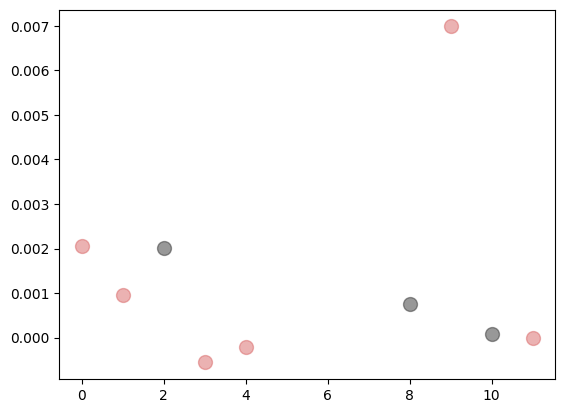

In [155]:
plt.figure()
for ind,ele in enumerate(allStore.keys()):
  if 'Opto' not in allStore[ele]:continue
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Opto']),s=100,color=cc1)

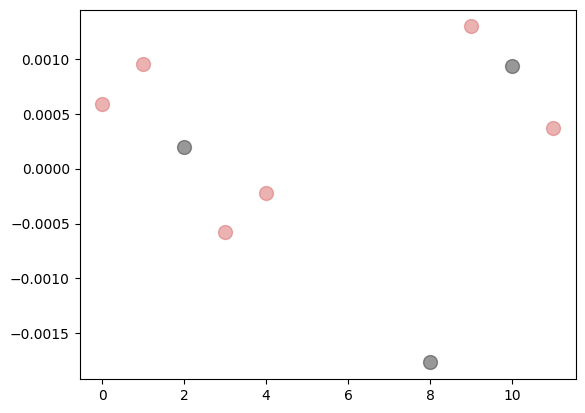

In [158]:
plt.figure()
for ind,ele in enumerate(allStore.keys()):
  if 'Opto' not in allStore[ele]:continue
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Opto']),s=100,color=cc1)

In [ ]:
plt.scatter(ind,np.nanmean(allStore[ele]['Opto']),s=100,color=cc1)

# Shaded Preference

In [28]:
findBees = glob.glob('/content/biol470/final_project/*/assay3*')

for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}

  allStore[bees.split('/')[-2]]['Shade'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([x_store[ind],y_store[ind]])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Shade'].append(speed)

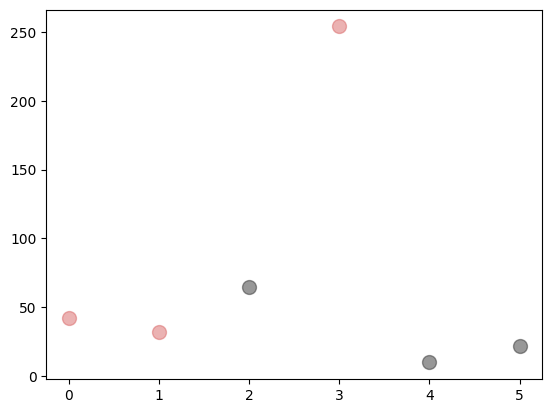

In [29]:
plt.figure()
nbee = {}
cbee = {}

for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
    nbee[ele] = np.nanmean(allStore[ele]['Shade'])
  else:
    cc1 = (0.2,0.2,0.2,0.5)
    cbee[ele] = np.nanmean(allStore[ele]['Shade'])



  plt.scatter(ind,np.nanmean(allStore[ele]['Shade']),s=100,color=cc1)

# Air Responses

In [26]:
findBees = glob.glob('/content/biol470/final_project/*/assay4*')

allStore = {}
for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}
  allStore[bees.split('/')[-2]]['Air'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  #plt.figure()
  #plt.plot(x_store,y_store)
  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([3200,1500])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Air'].append(speed)


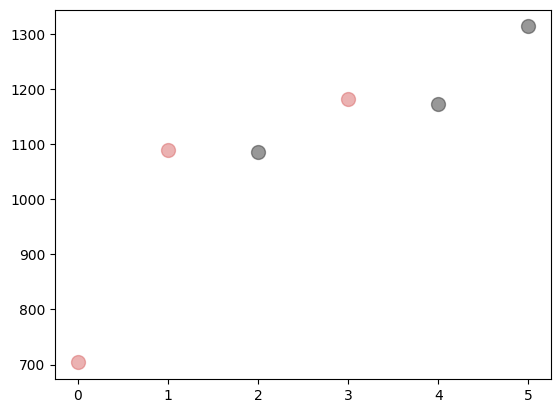

In [27]:
plt.figure()
for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Air']),s=100,color=cc1)

# Citronella Responses

In [29]:
findBees = glob.glob('/content/biol470/final_project/*/assay5*')

allStore = {}
for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}
  allStore[bees.split('/')[-2]]['Cit'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([4000,2000])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Cit'].append(speed)


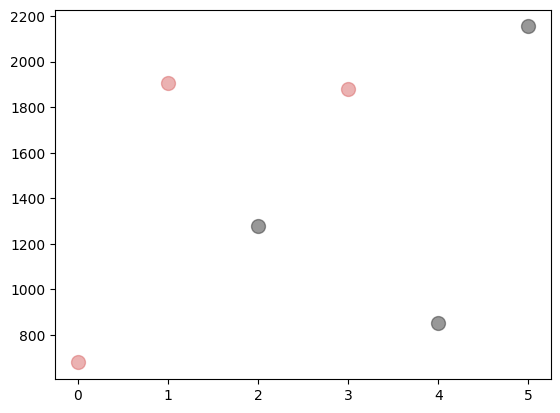

In [30]:
plt.figure()
for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Cit']),s=100,color=cc1)

# Linalool Responses

In [32]:
findBees = glob.glob('/content/biol470/final_project/*/assay6*')

allStore = {}
for bees in findBees:

  if bees.split('/')[-2] not in allStore:
    allStore[bees.split('/')[-2]] = {}
  allStore[bees.split('/')[-2]]['Lin'] = []

  data1 = pd.read_csv(bees)
  x_store = []
  y_store = []

  # Pulling out the centroid for each detection event
  for ind,ele in enumerate(data1['x_min']):
    x_center = (ele+data1['x_max'][ind])/2
    y_center = (data1['y_min'][ind]+data1['y_max'][ind])/2
    x_store.append(x_center)
    y_store.append(y_center)

  speed = []
  # updating to euclidean distance
  for ind,x1 in enumerate(x_store[1:]):
    previous_pos = np.array([4000,2000])
    current_pos = np.array([x_store[ind+1],y_store[ind+1]])

    # Euclidean distance calculation
    temp = np.linalg.norm((current_pos-previous_pos))
    speed.append(temp)

  allStore[bees.split('/')[-2]]['Lin'].append(speed)


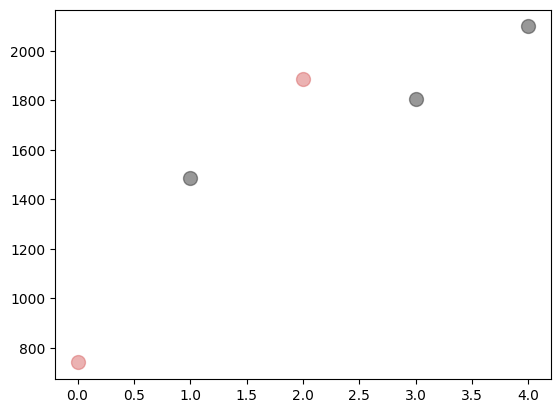

In [33]:
plt.figure()
for ind,ele in enumerate(allStore):
  if 'nic' in ele:
    cc1 = (0.85,0.4,0.4,0.5)
  else:
    cc1 = (0.2,0.2,0.2,0.5)

  plt.scatter(ind,np.nanmean(allStore[ele]['Lin']),s=100,color=cc1)

In [ ]:
!unzip /content/frames.zip

In [14]:
import cv2 as cv

In [15]:
in1 = cv.imread('/content/frames/bee_0408_2/final_bee_0408_2_air_cam1_2026-04-08_17-10-27.jpg')

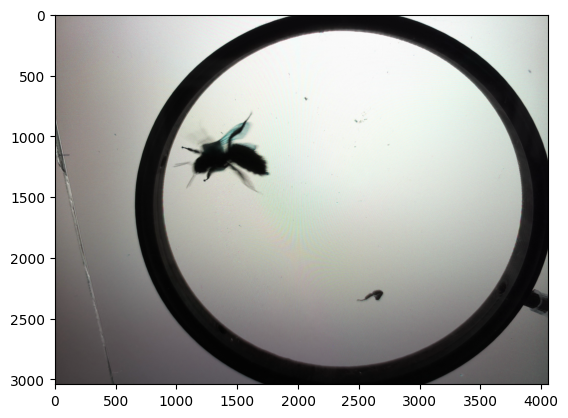

In [16]:
plt.imshow(in1)

In [17]:
in1 = cv.imread('/content/frames/bee_0408_3/final_bee_test_cit_cam1_2026-04-08_17-46-11.jpg')

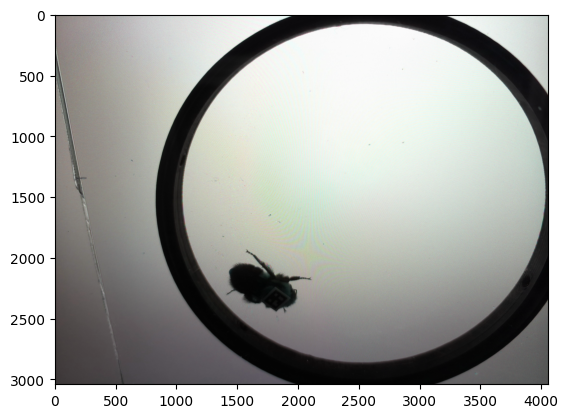

In [18]:
plt.imshow(in1)